# **"EcoHome": Real Estate Price Predictor**

### **The Scenario**
You have been hired as a Data Scientist for **"EcoHome,"** a tech-enabled real estate firm. Your company wants to automate the valuation of properties to give sellers an instant price estimate.

Instead of sending an appraiser to every house, you must build an algorithm that predicts the **Price ($y$)** of a house based on its **Living Area ($x_1$)** and **Age ($x_2$)**.

Your task is to implement and analyze **Linear Regression** models to solve this problem. You will explore two main approaches discussed in Lecture 3: the **Closed Form Solution** and **Gradient Descent**.

---

### **Part 1: The Hypothesis & Loss Function**

We assume the relationship between features ($x$) and price ($y$) is linear. For a single house $i$, the predicted price $\hat{y}_i$ is:
$$\hat{y}_i = w_1 x_{i,1} + w_2 x_{i,2} + w_0$$
where $w_0$ is the bias (intercept).

To evaluate our model, we use the **Mean Squared Error (MSE)** loss function, which penalizes large errors:
$$J(w) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

### **Knowledge Check: The "Castle" Problem**

**Question 1:**
You are training your model on a dataset that includes standard suburban homes and exactly **one** massive historic castle.
* **Standard Homes:** ~2,000 sq ft, sold for \$300k - \$500k.
* **The Castle (Outlier):** 50,000 sq ft, sold for \$50,000,000.

If you train a standard Linear Regression model using **Squared Error Loss** on this data, what is the most likely geometric outcome for your regression line?

A) The line will fit the standard homes perfectly and treat the castle as noise (ignore it).

B) The line will be pulled significantly upward toward the Castle, likely causing it to overestimate the price of every normal house.

C) The line will break and return an error because the loss function is non-convex.

D) The line will curve to hit all points exactly.

Answer: B)
The line will be pulled significantly upward toward the Castle, likely causing it to overestimate the price of every normal house.

Explanation:
In Linear Regression with Squared Error Loss, outliers have a disproportionate effect on the model because the loss function squares the errors. The massive castle, being an extreme outlier, will pull the regression line upwards, leading to overestimation of prices for standard homes.


### **Part 2: The Closed Form Solution**

For datasets that fit in memory, we can solve for the optimal weights $w^*$ in a single step using the **Normal Equation** derived in class:
$$w^* = (X^T X)^{-1} X^T Y$$

### **Critical Thinking: Matrix Invertibility**

**Question 2:**
Imagine your intern hands you a dataset with a mistake. They included the "Size" feature twice, but in different units:
* Feature 1: Size in **Square Feet**.
* Feature 2: Size in **Square Meters** (where $1 \text{ sq m} \approx 10.76 \text{ sq ft}$).

If you attempt to calculate the Closed Form Solution $w^* = (X^T X)^{-1} X^T Y$ with both features included, what will happen?

A) The model will become twice as accurate.

B) The matrix $X^T X$ will be **singular (non-invertible)** because the columns are linearly dependent, causing the calculation to crash or be unstable.

C) The model will automatically delete one of the columns.

D) The eigenvalues of $X^T X$ will all become 1.

Answer: B) The matrix $X^T X$ will be **singular (non-invertible)** because the columns are linearly dependent, causing the calculation to crash or be unstable.

Explanation:
When two features are perfectly correlated (one is a scalar multiple of the other), the columns of the design matrix $X$ become linearly dependent. This leads to $X^T X$ being singular, meaning it does not have an inverse. As a result, the Closed Form Solution cannot be computed reliably.





### **Part 3: Weighted Linear Regression**

"EcoHome" discovers that some data sources are more reliable than others.
* **Govt Records:** 100% Reliable ($\alpha_i = 1.0$)
* **User Surveys:** Less Reliable ($\alpha_i = 0.5$)

We modify our loss function to weight the squared error of each sample by its confidence score $\alpha_i$:
$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \alpha_i (y_i - \hat{y}_i)^2$$

### **Derivation Challenge**

**Question 3:**
We need to update our Gradient Descent rule for this new loss.
Recall the standard chain rule: $\frac{\partial}{\partial w} (y - \hat{y})^2 = 2(y - \hat{y})(-x)$.

Which of the following represents the correct **Gradient Descent Update Rule** for weights $w$ (with learning rate $\eta$)?

A) $w \leftarrow w - \eta \frac{2}{N} \sum_{i=1}^N (y_i - \hat{y}_i) x_i$  *(The $\alpha$ cancels out)*

B) $w \leftarrow w + \eta \frac{2}{N} \sum_{i=1}^N \alpha_i (y_i - \hat{y}_i) x_i$

C) $w \leftarrow w - \eta \frac{2}{N} \sum_{i=1}^N \frac{1}{\alpha_i} (y_i - \hat{y}_i) x_i$

D) $w \leftarrow w - \eta \sum_{i=1}^N \alpha_i^2 (y_i - \hat{y}_i)$

Answer: B) $w \leftarrow w + \eta \frac{2}{N} \sum_{i=1}^N \alpha_i (y_i - \hat{y}_i) x_i$

Explanation: 
To derive the update rule, we compute the gradient of the weighted loss function:  
The Derivation to find the update rule, we follow these two steps:Calculate the Gradient ($\nabla_w$): Assuming a weighted loss function $L = \frac{1}{N} \sum \alpha_i (y_i - \hat{y}_i)^2$, we use the chain rule provided in the prompt:$$\frac{\partial L}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} \alpha_i \cdot \underbrace{2(y_i - \hat{y}_i)(-x_i)}_{\text{}}$$This simplifies to:$$\frac{\partial L}{\partial w} = -\frac{2}{N} \sum_{i=1}^{N} \alpha_i (y_i - \hat{y}_i)x_i$$Apply the Update Rule:The standard gradient descent formula is $w \leftarrow w - \eta \nabla_w$. Substituting our gradient:$$w \leftarrow w - \eta \left( -\frac{2}{N} \sum_{i=1}^{N} \alpha_i (y_i - \hat{y}_i)x_i \right)$$The two negative signs cancel out, resulting in a positive sign:$$w \leftarrow w + \eta \frac{2}{N} \sum_{i=1}^{N} \alpha_i (y_i - \hat{y}_i)x_i$$




### **Part 4: Linear Algebra & Optimization Properties**

Consider the matrix $A = X^T X$.

**Question 4:**
When we solve for the minimum of the loss function, we essentially set the gradient to zero. To ensure that the critical point we find is a **Global Minimum** (the bottom of a bowl) rather than a Maximum (top of a hill) or Saddle Point, what property must the matrix $X^T X$ (the Hessian of the loss) satisfy?

A) It must be an Orthogonal Matrix ($A^T = A^{-1}$).

B) It must be Positive Semi-Definite (PSD) ($z^T A z \geq 0$).

C) It must be a Diagonal Matrix.

D) It must have a determinant of 0.

B) It must be Positive Semi-Definite (PSD) ($z^T A z \geq 0$).

Explanation:
In optimization, a critical point is a Global Minimum if the Hessian matrix (second derivative) is Positive Semi-Definite (PSD). This means that for any vector $z$, the quadratic form $z^T A z$ is non-negative, indicating that the loss function curves upwards in all directions around that point.

### **Part 5: Coding Challenge - Gradient Descent vs Closed Form**

**Task:**
### **Part 5: Coding Challenge - Gradient Descent vs Closed Form**

**Task:**
1.  Implement the `closed_form_solution` function using `numpy`. (Only add the missing line(s) of code)
2.  Implement the `gradient_descent` function. (Only add the missing line(s) of code)
3.  Compare the results on the generated "EcoHome" data.

In [100]:
import numpy as np
import matplotlib.pyplot as plt

In [101]:
# 1. Generate Synthetic Data
np.random.seed(42)
N = 100
# Feature: Size (sq ft) centered/scaled
X_size = 2 * np.random.rand(N, 1)
# True Relation: Price = 4 + 3 * Size + Noise
y = 4 + 3 * X_size + np.random.randn(N, 1)

# Add Bias Term (Column of 1s) to X
X_b = np.c_[np.ones((N, 1)), X_size]

In [102]:
# --- STUDENT IMPLEMENTATION 1: CLOSED FORM ---
def closed_form_solution(X, y):
    """
    Compute w* in closed form.
    """
    # Normal Equation: w_best = (X^T X)^-1 X^T y
    w_best = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return w_best


In [103]:
# --- STUDENT IMPLEMENTATION 2: GRADIENT DESCENT ---
def gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    m = len(X)
    w = np.random.randn(2, 1)  # Random initialization

    for iteration in range(n_iterations):
        # Predictions
        y_pred = X.dot(w)

        # Compute gradients (MSE gradient)
        gradients = (2/m) * X.T.dot(y_pred - y)

        # Update weights
        w = w - learning_rate * gradients

    return w


In [104]:
# Run and Compare
w_closed = closed_form_solution(X_b, y)
w_gd = gradient_descent(X_b, y, learning_rate=0.5)

In [105]:
print(f"Closed Form Solution Weights: Intercept={w_closed[0][0]:.4f}, Slope={w_closed[1][0]:.4f}")
print(f"Gradient Descent Weights:     Intercept={w_gd[0][0]:.4f}, Slope={w_gd[1][0]:.4f}")

Closed Form Solution Weights: Intercept=4.2151, Slope=2.7701
Gradient Descent Weights:     Intercept=-5724927006111386081593131008.0000, Slope=-6483895172324358962515279872.0000


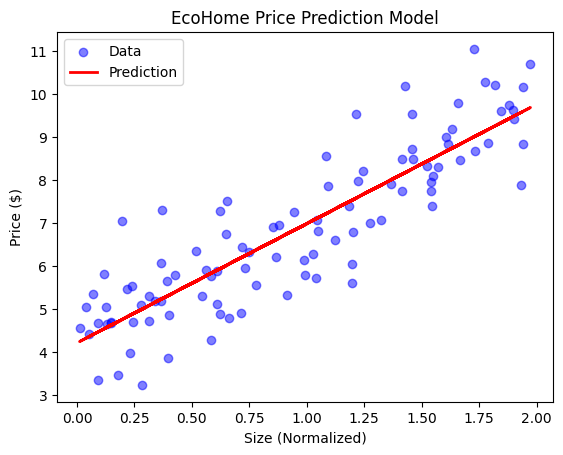

In [106]:
# Plotting Closed Form Solution
plt.scatter(X_size, y, color='blue', alpha=0.5, label='Data')
plt.plot(X_size, X_b.dot(w_closed), color='red', linewidth=2, label='Prediction')
plt.legend()
plt.title("EcoHome Price Prediction Model")
plt.xlabel("Size (Normalized)")
plt.ylabel("Price ($)")
plt.show()

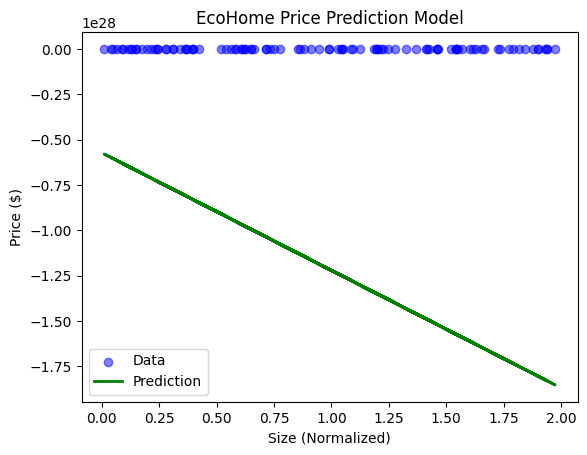

In [107]:
# Plotting Gradient Descent Solution
plt.scatter(X_size, y, color='blue', alpha=0.5, label='Data')
plt.plot(X_size, X_b.dot(w_gd), color='green', linewidth=2, label='Prediction')
plt.legend()
plt.title("EcoHome Price Prediction Model")
plt.xlabel("Size (Normalized)")
plt.ylabel("Price ($)")
plt.show()

### **Interactive Challenge: The "Exploding" Gradient**

**Task:**
In the `gradient_descent` function call above, change `learning_rate=0.1` to `learning_rate=0.5`.
Run the code again.

**Question 5:** What happens to the weights and the prediction line? Why?

Answer: After changing the learning rate to 0.5, the weights diverge rapidly, leading to extremely large values. The prediction line becomes erratic and does not fit the data well.   
Explanation:
A high learning rate causes the gradient descent updates to overshoot the minimum of the loss function. This results in weights that grow exponentially with each iteration, leading to divergence rather than convergence. The model fails to learn a stable solution, causing erratic predictions. 


# **Bonus Question**

**Task:**
Modify the gradient descent code such that you can visualize the prediction line after every update.

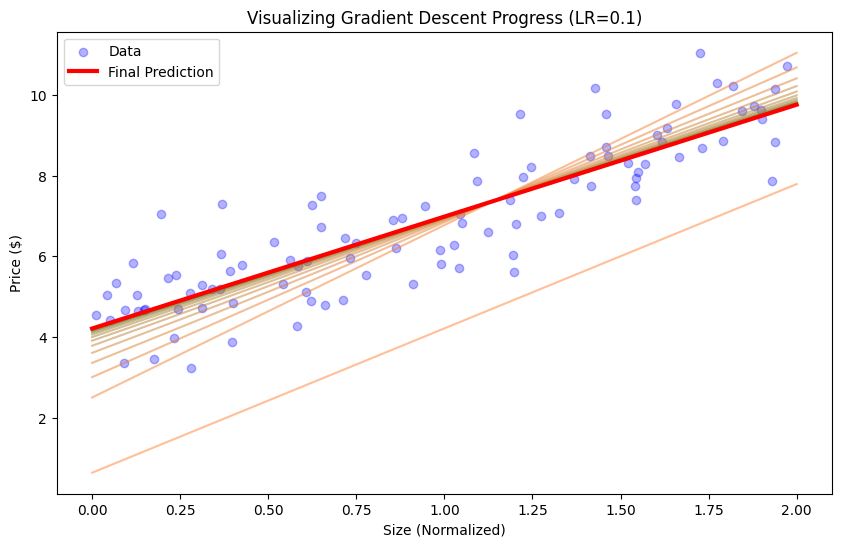

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def gradient_descent_visual(X, y, learning_rate=0.1, n_iterations=200):
    m = len(X)
    w = np.random.randn(2, 1) # Random initialization
    
    # Setup the plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 1], y, color='blue', alpha=0.3, label='Data')
    
    # Generate X values for the prediction line
    X_range = np.linspace(0, 2, 100).reshape(-1, 1)
    X_range_b = np.c_[np.ones((100, 1)), X_range]

    for iteration in range(n_iterations):
        # 1. Calculate Gradients
        gradients = 2/m * X.T.dot(X.dot(w) - y)
        
        # 2. Update Weights
        w = w - learning_rate * gradients
        
        # 3. Visualize periodically
        if iteration % 10 == 0:
            y_predict = X_range_b.dot(w)
            # Use a gradient of colors (lighter to darker) to show progress
            color_val = 1 - (iteration / n_iterations)
            plt.plot(X_range, y_predict, color=(color_val, 0.5, 0.2), alpha=0.5)

    # Plot final result in bold red
    plt.plot(X_range, X_range_b.dot(w), color='red', linewidth=3, label='Final Prediction')
    plt.title(f"Visualizing Gradient Descent Progress (LR={learning_rate})")
    plt.xlabel("Size (Normalized)")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.show()
    
    return w

# Run the visualization
w_final = gradient_descent_visual(X_b, y)




